# Laptop Data

In [1]:
import pandas as pd
import numpy as np
import regex as re

In [2]:
df = pd.read_csv('D:/Python - Reinforcement Project/Reinforcement Project - Python/Laptop Dataset/laptopData.csv')

In [3]:
df.head(10)

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
5,5.0,Acer,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,21312.0000
6,6.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,114017.6016
7,7.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,61735.5360
8,8.0,Asus,Ultrabook,14,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,512GB SSD,Nvidia GeForce MX150,Windows 10,1.3kg,79653.6000
9,9.0,Acer,Ultrabook,14,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,41025.6000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1273 non-null   float64
 1   Company           1273 non-null   object 
 2   TypeName          1253 non-null   object 
 3   Inches            1220 non-null   object 
 4   ScreenResolution  1273 non-null   object 
 5   Cpu               1273 non-null   object 
 6   Ram               1259 non-null   object 
 7   Memory            1273 non-null   object 
 8   Gpu               1273 non-null   object 
 9   OpSys             1273 non-null   object 
 10  Weight            1259 non-null   object 
 11  Price             1273 non-null   float64
dtypes: float64(2), object(10)
memory usage: 122.3+ KB


### Structure of the Table (Rows,Columns)

In [5]:
df.shape

(1303, 12)

### Count null values by columns

In [6]:
df.isnull().sum()

Unnamed: 0          30
Company             30
TypeName            50
Inches              83
ScreenResolution    30
Cpu                 30
Ram                 44
Memory              30
Gpu                 30
OpSys               30
Weight              44
Price               30
dtype: int64

### Find Duplicates

In [7]:
df.duplicated().sum()

29

### Remove Duplicates

In [8]:
df.drop_duplicates(inplace=True)

### Remove Unwanted column

In [9]:
df.drop('Unnamed: 0',axis=1,inplace=True)

### Drop rows with NaN in all columns

In [10]:
df.dropna(how='all',inplace=True)

# Clean Inches Column
- Minimum Screen Size ~10"
- maximum Screen Size ~20"

### Fill missing Values for Inches

In [11]:
df['Inches'].isna().sum()

53

### Fill NaN with 0 in Inches

In [12]:
df['Inches'] = df['Inches'].fillna(0) 

### Change "?" value to 0

In [13]:
df.replace('?',0,inplace=True)

In [ ]:
df['Inches'].unique().tolist()

### Change Datatype for Inches Column

In [15]:
df['Inches']=df['Inches'].astype(float)

### Find median and fill 0 with it

In [16]:
median_inches = df.loc[df['Inches'] <= 20, 'Inches'].median()

In [17]:
df.loc[df['Inches'] > 20, 'Inches'] = median_inches
df.loc[df['Inches'] < 10, 'Inches'] = median_inches

# Clean Weight Column

### Split NON-numeric from Weight and change datatype
- Minimum Weight of Laptop ~900g
- Maximum Weight of Laptop ~5.5kg

In [18]:
df['Weight'].isna().sum()

14

In [19]:
df.rename(columns={'Weight':'Weight (kg)','Ram':'Ram (GB)'})

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram (GB),Memory,Gpu,OpSys,Weight (kg),Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,Lenovo,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [ ]:
df['Weight'].unique().tolist()

### Replace "?" with 0

In [21]:
df['Weight'] = df['Weight'].replace('?',0)

### Fill nan with 0

In [22]:
df['Weight'] = df['Weight'].fillna(0)

### Remove non_numerical value 'kg' 

In [23]:
df['Weight'] = df['Weight'].str.lower().str.replace('kg', '').str.strip()

### Change Datatype

In [24]:
df['Weight'] = df['Weight'].astype(float)

### Find Median for weight between 0.9 - 5.5 

In [25]:
median_weight = df[(df['Weight'] >= 0.9) & (df['Weight'] <= 5.5)]['Weight'].median()
median_weight

2.04

### Replace 0 with nan and fill with median

In [26]:
df['Weight'] = df['Weight'].replace(0,np.nan).fillna(median_weight)

### Fill below 0.9 and above 5.5 with median_weight

In [27]:
df.loc[(df['Weight'] < 0.9) | (df['Weight'] > 5.5), 'Weight'] = median_weight

In [28]:
df['Weight'] = df['Weight'].round(2)

# Clean TypeName column
- Fill unknown based on Weight
    - Ultrabook less than 1.5kg
    - notebook >=1.5kg and <=2.5kg
    - gaming >2.5kg

In [134]:
df['TypeName'].value_counts()

TypeName
notebook       733
gaming         203
ultrabook      194
convertible    114
workstation     29
Name: count, dtype: int64

In [133]:
df['TypeName'].unique()

array(['ultrabook', 'notebook', 'gaming', 'convertible', 'workstation'],
      dtype=object)

In [132]:
df['TypeName']=df['TypeName'].replace({'2 in 1 Convertible': 'Convertible','netbook':'notebook'})

In [32]:
df['TypeName']=df['TypeName'].fillna('Unknown')

In [33]:
df['TypeName']=df['TypeName'].str.lower().str.strip()

In [34]:
df.loc[(df['TypeName'] == 'unknown') & (df['Weight'] < 1.5),'TypeName'] = 'ultrabook'

In [35]:
df.loc[(df['TypeName'] == 'unknown') & (df['Weight'] >= 1.5) & (df['Weight'] <= 2.5),
'TypeName'] = 'notebook'

In [36]:
df.loc[(df['TypeName'] == 'unknown') & (df['Weight'] > 2.5),'TypeName'] = 'gaming'

In [37]:
df['TypeName'].value_counts()

TypeName
notebook       709
gaming         203
ultrabook      194
convertible    114
workstation     29
netbook         24
Name: count, dtype: int64

# Clean Company Column

In [38]:
df['Company'].value_counts()

Company
Lenovo       290
Dell         287
HP           266
Asus         156
Acer         103
MSI           53
Toshiba       47
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
LG             3
Huawei         2
Fujitsu        2
Name: count, dtype: int64

In [39]:
df['Company'] = df['Company'].replace('Vero', 'Acer')

### Clean ScreenResolution Column

- Extract Width and Height from the ScreenResolution column

In [40]:
df[['ResolutionWidth', 'ResolutionHeight']] = df['ScreenResolution'].str.extract(r'(\d{3,4})x(\d{3,4})').astype(int)

In [41]:
df['Touchscreen'] = df['ScreenResolution'].str.contains('Touchscreen', case=False, na=False).astype(int)

In [42]:
df['TotalPixels'] = df['ResolutionWidth'] * df['ResolutionHeight']

In [43]:
def resolution_group(pixels):
    if pixels >= 8000000:
        return '4K'
    elif pixels >= 4000000:
        return 'QHD+'
    elif pixels >= 2000000:
        return 'Full HD'
    else:
        return 'HD or Below'

df['ResolutionCategory'] = df['TotalPixels'].apply(resolution_group)

In [44]:
df.groupby('Touchscreen')['TotalPixels'].mean()

Touchscreen
0    1.967933e+06
1    3.340850e+06
Name: TotalPixels, dtype: float64

In [45]:
high_end = df[(df['TotalPixels'] > 4000000) & (df['Touchscreen'] == 1)]

In [46]:
def get_display_type(x):
    x = x.lower()
    if 'touchscreen' in x:
        return 'Touchscreen'
    elif 'ips' in x:
        return 'IPS'
    elif 'retina' in x:
        return 'Retina'
    elif '4k' in x:
        return '4K'
    elif 'quad hd+' in x:
        return 'QHD+'
    elif 'full hd' in x:
        return 'Full HD'
    elif 'hd' in x:
        return 'HD'
    else:
        return 'Standard'

df['DisplayType'] = df['ScreenResolution'].apply(get_display_type)


### Clean cpu

In [88]:
df['CpuBrand'] = df['Cpu'].str.split().str[0]

In [89]:
cpu_words = df['Cpu'].str.split()

In [49]:
# Create new columns for 2nd and 3rd words safely
df['CpuModel1'] = cpu_words.str.get(1).fillna('')
df['CpuModel2'] = cpu_words.str.get(2).fillna('')

In [50]:
# Combine model words (with a space, but avoid trailing spaces if second word missing)
df['CpuModel'] = df['CpuModel1'] + df['CpuModel2'].replace('', ' ')
df['CpuModel'] = df['CpuModel'].str.strip()

In [51]:
# Extract CPU speed (GHz) as float
df['CpuSpeedGHz'] = df['Cpu'].str.extract(r'(\d+\.?\d*)GHz')[0].astype(float)

In [52]:
df.drop(['CpuModel1', 'CpuModel2'], axis=1, inplace=True)

In [53]:
df['CpuCategory'] = df['CpuModel'].replace({
    'Corei3': 'Intel Core i3',
    'Corei5': 'Intel Core i5',
    'Corei7': 'Intel Core i7',
    'Corem3': 'Intel Core M',
    'Ryzen': 'AMD Ryzen',
    'A9-Series': 'AMD A9',
    'A6-Series': 'AMD A6',
    'A8-Series': 'AMD A8',
    'A10-Series': 'AMD A10',
    'A12-Series': 'AMD A12',
    'E-Series': 'AMD E-Series',
    'Pentium': 'Intel Pentium',
    'Celeron': 'Intel Celeron',
    'Atom': 'Intel Atom',
    'Xeon': 'Intel Xeon',
    'FX': 'AMD FX',
})


### Cleaning 'Ram' column

In [54]:
df['Ram'].unique().tolist()

['8GB',
 '16GB',
 '4GB',
 nan,
 '2GB',
 '12GB',
 '64GB',
 '6GB',
 '32GB',
 '24GB',
 '1GB']

In [55]:
#df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)

In [56]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,ResolutionWidth,ResolutionHeight,Touchscreen,TotalPixels,ResolutionCategory,DisplayType,CpuBrand,CpuModel,CpuSpeedGHz,CpuCategory
0,Apple,ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,...,2560,1600,0,4096000,QHD+,IPS,Intel,Corei5,2.3,Intel Core i5
1,Apple,ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,...,1440,900,0,1296000,HD or Below,Standard,Intel,Corei5,1.8,Intel Core i5
2,HP,notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86,...,1920,1080,0,2073600,Full HD,Full HD,Intel,Corei5,2.5,Intel Core i5
3,Apple,ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83,...,2880,1800,0,5184000,QHD+,IPS,Intel,Corei7,2.7,Intel Core i7
4,Apple,ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,...,2560,1600,0,4096000,QHD+,IPS,Intel,Corei5,3.1,Intel Core i5


In [57]:
# Remove 'GB' and convert to integer
df['Ram'] = df['Ram'].str.replace('GB', '').astype('float')

In [58]:
df['Ram'] = df['Ram'].fillna(0)

In [59]:
df['Ram'] = df['Ram'].astype('int')

In [60]:
mode_ram = df['Ram'].mode()[0]
df['Ram'] = df['Ram'].replace(0, mode_ram)

### Memory cleaning

In [61]:
df['Memory'].value_counts()

Memory
256GB SSD                        401
1TB HDD                          217
500GB HDD                        130
512GB SSD                        116
128GB SSD +  1TB HDD              92
128GB SSD                         74
256GB SSD +  1TB HDD              71
32GB Flash Storage                37
2TB HDD                           16
64GB Flash Storage                14
512GB SSD +  1TB HDD              14
1TB SSD                           13
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          4
128GB Flash Storage                4
512GB SSD +  2TB HDD               3
16GB SSD                           3
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
128GB SSD +  2TB HDD               2
256GB SSD +  500GB HDD             2
256GB SSD +  256GB SSD             2
512GB SSD +  256GB SSD         

In [62]:
df['Memory'] = df['Memory'].str.replace('TB', '000GB')

In [63]:
df['PrimaryStorageSizeGB'] = df['Memory'].str.extract(r'(\d+)GB').astype(float)

In [64]:
memory_mode=df['Memory'].mode()[0]
df['Memory']=df['Memory'].replace(0,memory_mode)

In [65]:
df['Memory'] = df['Memory'].str.replace('TB', '000GB')

In [66]:
df['PrimaryStorageType'] = df['Memory'].str.extract(r'GB\s*([a-zA-Z]+)')

In [67]:
mode_memory = df['Memory'].mode()[0]
df['Memory'] = df['Memory'].replace(0, mode_memory)

In [68]:
df[df['Memory'].str.contains('1.0000GB', na=False)]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,Touchscreen,TotalPixels,ResolutionCategory,DisplayType,CpuBrand,CpuModel,CpuSpeedGHz,CpuCategory,PrimaryStorageSizeGB,PrimaryStorageType
151,Dell,gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,1.0000GB Hybrid,Nvidia GeForce GTX 1050,Windows 10,2.62,...,0,2073600,Full HD,Full HD,Intel,Corei7,2.8,Intel Core i7,0.0,Hybrid
1010,Dell,gaming,15.6,Full HD 1920x1080,Intel Core i5 7300HQ 2.5GHz,8,1.0000GB Hybrid,Nvidia GeForce GTX 1050,Windows 10,2.65,...,0,2073600,Full HD,Full HD,Intel,Corei5,2.5,Intel Core i5,0.0,Hybrid
1075,Lenovo,notebook,15.6,1600x900,Intel Core i5 6200U 2.3GHz,8,1.0000GB HDD,AMD Radeon R5 M330,Windows 10,3.00,...,0,1440000,HD or Below,Standard,Intel,Corei5,2.3,Intel Core i5,0.0,HDD
1081,Lenovo,gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6820HK 2.7GHz,32,512GB SSD + 1.0000GB Hybrid,Nvidia GeForce GTX 980M,Windows 10,4.60,...,0,2073600,Full HD,IPS,Intel,Corei7,2.7,Intel Core i7,512.0,SSD
1116,Lenovo,gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6820HK 2.7GHz,16,256GB SSD + 1.0000GB Hybrid,Nvidia GeForce GTX 980M,Windows 10,4.60,...,0,2073600,Full HD,IPS,Intel,Corei7,2.7,Intel Core i7,256.0,SSD
1135,Lenovo,notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,16,1.0000GB Hybrid,AMD Radeon R7 M360,Windows 10,2.50,...,0,2073600,Full HD,Full HD,Intel,Corei7,2.5,Intel Core i7,0.0,Hybrid
1158,Lenovo,notebook,15.6,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8,1.0000GB Hybrid,AMD Radeon R5 M330,Windows 10,2.50,...,0,2073600,Full HD,Full HD,Intel,Corei5,2.3,Intel Core i5,0.0,Hybrid
1176,Lenovo,notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,4,1.0000GB Hybrid,Intel HD Graphics 520,Windows 7,2.32,...,0,2073600,Full HD,Full HD,Intel,Corei7,2.5,Intel Core i7,0.0,Hybrid
1258,Lenovo,notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,8,1.0000GB Hybrid,AMD Radeon R5 M330,Windows 7,2.32,...,0,2073600,Full HD,Full HD,Intel,Corei7,2.5,Intel Core i7,0.0,Hybrid
1266,HP,notebook,15.6,Full HD 1920x1080,AMD A9-Series 9410 2.9GHz,6,1.0000GB Hybrid,AMD Radeon R7 M440,Windows 10,2.04,...,0,2073600,Full HD,Full HD,AMD,A9-Series9410,2.9,A9-Series9410,0.0,Hybrid


In [69]:
df['Memory'] = df['Memory'].replace('1.0000GB HDD', '1TB')

In [70]:
df['Memory'] = df['Memory'].str.replace('Flash Storage', 'SSD')
df['Memory'] = df['Memory'].str.replace('Hybrid', 'HDD')

In [71]:
df['Memory'].isna().sum()

1

In [72]:
df['Memory'] = df['Memory'].replace('1.0000GB HDD', '10000GB')

In [73]:
df['Memory'].dropna(inplace=True)

In [74]:
df['Memory'].unique().tolist()

['128GB SSD',
 '256GB SSD',
 '512GB SSD',
 '500GB HDD',
 '1000GB HDD',
 '128GB SSD +  1000GB HDD',
 '256GB SSD +  256GB SSD',
 '64GB SSD',
 '32GB SSD',
 '256GB SSD +  1000GB HDD',
 '256GB SSD +  2000GB HDD',
 '2000GB HDD',
 '10000GB',
 '512GB SSD +  1000GB HDD',
 '1000GB SSD',
 '256GB SSD +  500GB HDD',
 '128GB SSD +  2000GB HDD',
 '512GB SSD +  512GB SSD',
 '16GB SSD',
 '512GB SSD +  256GB SSD',
 '512GB SSD +  2000GB HDD',
 '64GB SSD +  1000GB HDD',
 '180GB SSD',
 '1000GB HDD +  1000GB HDD',
 '32GB HDD',
 '1000GB SSD +  1000GB HDD',
 nan,
 '128GB HDD',
 '240GB SSD',
 '8GB SSD',
 '508GB HDD',
 '1TB',
 '512GB SSD +  1.0000GB HDD',
 '256GB SSD +  1.0000GB HDD']

In [75]:
df['Memory'] = df['Memory'].str.replace('1.0000GB', '1000GB', regex=False)


### Split on '+' into two parts

In [76]:
mem_split = df['Memory'].str.split('+', n=1, expand=True)
mem_split[0] = mem_split[0].str.strip()
mem_split[1] = mem_split[1].str.strip()  # Important to strip spaces


### function to convert size and type

In [77]:
def get_size_type(x):
    if pd.isna(x) or x.strip() == '0GB None':
        return pd.Series([0.0, 'None'])

    x = str(x).strip()

    # Extract size
    size = 0.0
    if 'TB' in x:
        size = float(x.lower().replace('tb', '').split()[0].strip()) * 1024
    elif 'GB' in x:
        size = float(x.lower().replace('gb', '').split()[0].strip())
    
    # Extract type (last word in the string)
    parts = x.split()
    storage_type = parts[-1] if len(parts) > 1 else 'Unknown'

    return pd.Series([size, storage_type])


In [78]:
df[['PrimaryStorageSizeGB', 'PrimaryStorageType']] = mem_split[0].apply(get_size_type)
df[['SecondaryStorageSizeGB', 'SecondaryStorageType']] = mem_split[1].apply(get_size_type)


In [79]:
df['Cpu'].unique()

array(['Intel Core i5 2.3GHz', 'Intel Core i5 1.8GHz',
       'Intel Core i5 7200U 2.5GHz', 'Intel Core i7 2.7GHz',
       'Intel Core i5 3.1GHz', 'AMD A9-Series 9420 3GHz',
       'Intel Core i7 2.2GHz', 'Intel Core i7 8550U 1.8GHz',
       'Intel Core i5 8250U 1.6GHz', 'Intel Core i3 6006U 2GHz',
       'Intel Core i7 2.8GHz', 'Intel Core M m3 1.2GHz',
       'Intel Core i7 7500U 2.7GHz', 'Intel Core i7 2.9GHz',
       'Intel Core i3 7100U 2.4GHz', 'Intel Core i5 7300HQ 2.5GHz',
       'AMD E-Series E2-9000e 1.5GHz', 'Intel Core i5 1.6GHz',
       'Intel Core i7 8650U 1.9GHz', 'Intel Atom x5-Z8300 1.44GHz',
       'AMD E-Series E2-6110 1.5GHz', 'AMD A6-Series 9220 2.5GHz',
       'Intel Celeron Dual Core N3350 1.1GHz',
       'Intel Core i3 7130U 2.7GHz', 'Intel Core i7 7700HQ 2.8GHz',
       'Intel Core i5 2.0GHz', 'AMD Ryzen 1700 3GHz',
       'Intel Pentium Quad Core N4200 1.1GHz',
       'Intel Celeron Dual Core N3060 1.6GHz', 'Intel Core i5 1.3GHz',
       'AMD FX 9830P 3GHz', '

In [80]:
def simple_cpu_clean(cpu):
    if pd.isna(cpu):
        return pd.Series([None, None, None])
    
    parts = cpu.split()
    brand = parts[0]
    
    # Get CPU series (e.g., 'Core i5', 'Ryzen 7', 'A9-Series')
    if 'Core' in parts:
        idx = parts.index('Core')
        series = 'Core ' + parts[idx + 1]
    elif 'Ryzen' in parts:
        series = 'Ryzen ' + parts[parts.index('Ryzen') + 1]
    elif 'A4-Series' in cpu:
        series = 'A4-Series'
    elif 'A6-Series' in cpu:
        series = 'A6-Series'
    elif 'A8-Series' in cpu:
        series = 'A8-Series'
    elif 'A9-Series' in cpu:
        series = 'A9-Series'
    elif 'A10-Series' in cpu:
        series = 'A10-Series'
    elif 'A12-Series' in cpu:
        series = 'A12-Series'
    else:
        series = parts[1] if len(parts) > 1 else None

    # Get speed in GHz
    try:
        speed = float(cpu.strip().split()[-1].replace('GHz', '').replace(',', '.'))
    except:
        speed = None

    return pd.Series([brand, series, speed])


In [81]:
df[['CpuBrand', 'CpuSeries', 'CpuSpeedGHz']] = df['Cpu'].apply(simple_cpu_clean)

In [82]:
df['CpuSpeedGHz'].value_counts()

CpuSpeedGHz
2.50    286
2.80    161
2.70    160
1.60    129
2.30     84
2.00     84
1.80     77
2.60     75
1.10     53
2.40     52
2.90     21
3.00     19
1.20     15
2.20     11
1.50     10
1.44     10
1.30      6
3.60      5
0.90      4
3.10      3
2.10      3
1.90      2
3.20      1
1.00      1
1.92      1
Name: count, dtype: int64

In [83]:
df.columns.tolist()

['Company',
 'TypeName',
 'Inches',
 'ScreenResolution',
 'Cpu',
 'Ram',
 'Memory',
 'Gpu',
 'OpSys',
 'Weight',
 'Price',
 'ResolutionWidth',
 'ResolutionHeight',
 'Touchscreen',
 'TotalPixels',
 'ResolutionCategory',
 'DisplayType',
 'CpuBrand',
 'CpuModel',
 'CpuSpeedGHz',
 'CpuCategory',
 'PrimaryStorageSizeGB',
 'PrimaryStorageType',
 'SecondaryStorageSizeGB',
 'SecondaryStorageType',
 'CpuSeries']

In [ ]:
df['Gpu'].unique().tolist()

In [85]:
def extract_gpu_details(gpu):
    if pd.isna(gpu):
        return pd.Series([None, None])
    
    parts = gpu.strip().split()
    brand = parts[0].capitalize()
    model = ' '.join(parts[1:]) if len(parts) > 1 else None
    
    return pd.Series([brand, model])


In [86]:
df[['GpuBrand', 'GpuModel']] = df['Gpu'].apply(extract_gpu_details)

In [105]:
df['OpSys'].replace('Windows 10 S','Windows 10')
df['OpSys'] = df['OpSys'].replace({'macOS': 'Mac OS', 'Mac OS X': 'Mac OS'})


In [106]:
df['OpSys'].unique().tolist()

['Mac OS', 'No OS', 'Windows 10', 'Linux', 'Chrome OS', 'Windows 7', 'Android']

In [107]:
df['Price'].info()
df['Price'].isnull().sum()

<class 'pandas.core.series.Series'>
Index: 1273 entries, 0 to 1302
Series name: Price
Non-Null Count  Dtype  
--------------  -----  
1273 non-null   float64
dtypes: float64(1)
memory usage: 19.9 KB


0

In [ ]:
df['Price'].sort_values(ascending=False).unique().tolist()

# Exploratory Data Analysis (EDA)

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

In [117]:
plt.figure(figsize=(16, 10))

<Figure size 1600x1000 with 0 Axes>

<Figure size 1600x1000 with 0 Axes>

## Univariate Analysis

### Price Distribution

Text(0.5, 1.0, 'Distribution of Laptop Prices')

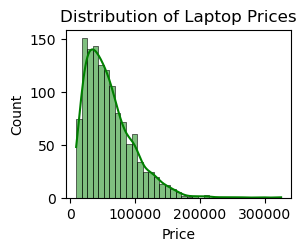

In [118]:
plt.subplot(2, 2, 1)
sns.histplot(df['Price'], kde=True, color='green')
plt.title('Distribution of Laptop Prices')

Text(0.5, 1.0, 'Distribution of Screen Size (Inches)')

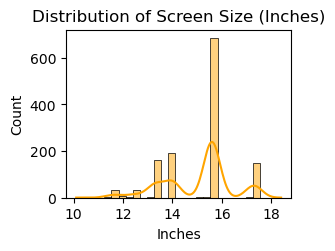

In [119]:
# Screen Size
plt.subplot(2, 2, 2)
sns.histplot(df['Inches'], kde=True, color='orange')
plt.title('Distribution of Screen Size (Inches)')

Text(0.5, 1.0, 'RAM Count Distribution')

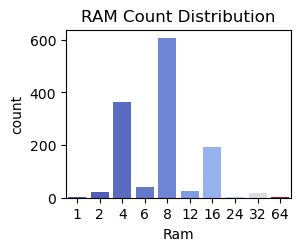

In [121]:
# RAM
plt.subplot(2, 2, 3)
sns.countplot(x='Ram', hue='Ram', data=df, palette='coolwarm', legend=False)
plt.title('RAM Count Distribution')

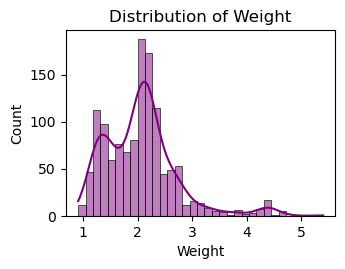

In [122]:
# Weight
plt.subplot(2, 2, 4)
sns.histplot(df['Weight'], kde=True, color='purple')
plt.title('Distribution of Weight')

plt.tight_layout()
plt.show()

#  Bivariate Analysis

###  Price vs RAM

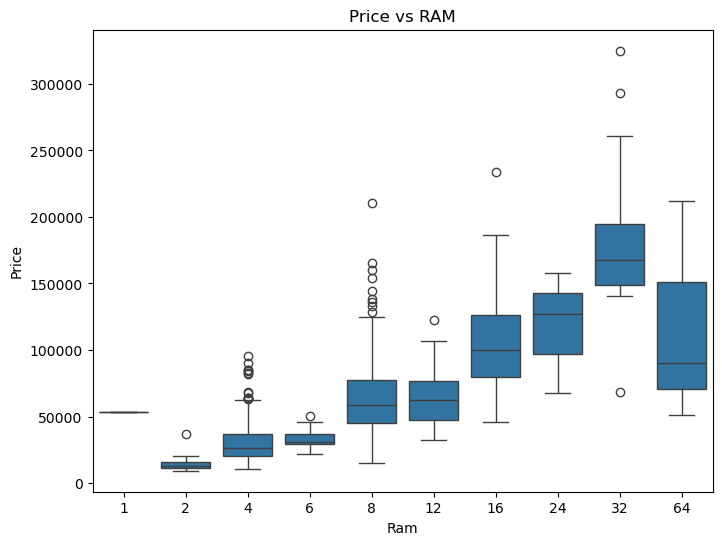

In [123]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Ram', y='Price', data=df)
plt.title('Price vs RAM')
plt.show()


### Price vs. Screen Size

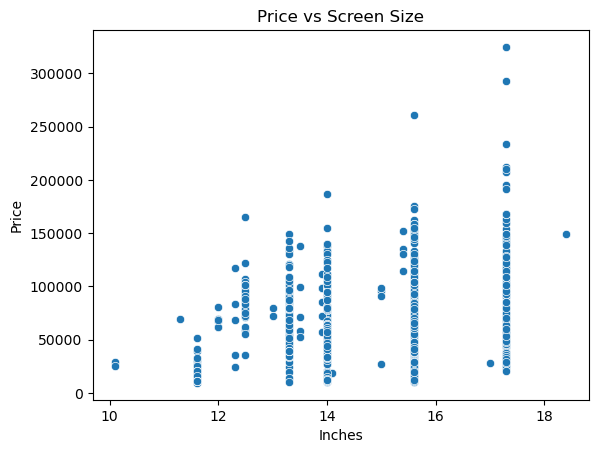

In [124]:
sns.scatterplot(x='Inches', y='Price', data=df)
plt.title('Price vs Screen Size')
plt.show()

### Price vs CPU Brand

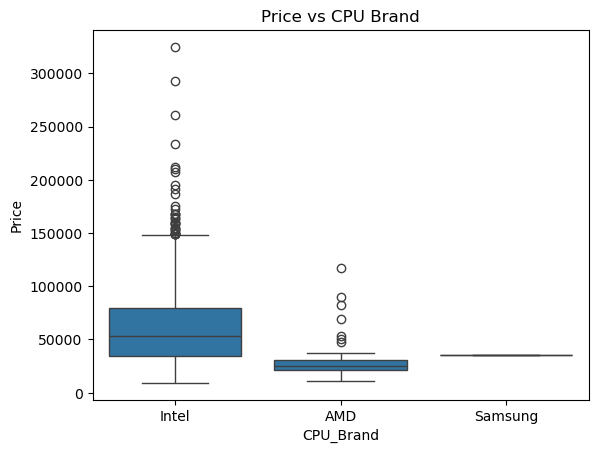

In [125]:
df['CPU_Brand'] = df['Cpu'].str.split().str[0]

sns.boxplot(x='CPU_Brand', y='Price', data=df)
plt.title('Price vs CPU Brand')
plt.show()

### Weight vs. Screen Size

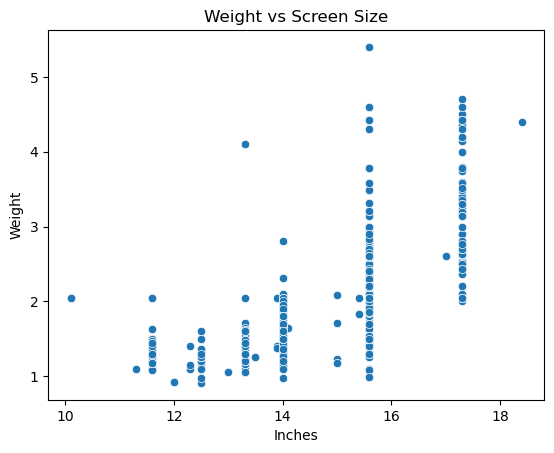

In [126]:
sns.scatterplot(x='Inches', y='Weight', data=df)
plt.title('Weight vs Screen Size')
plt.show()

# Multivariate Analysis

##  Correlation Heatmap

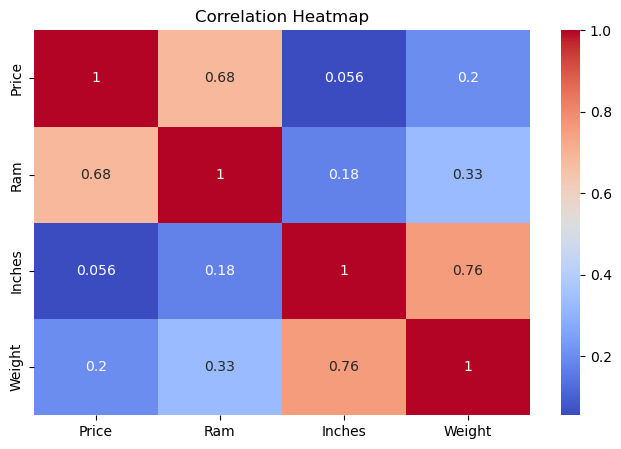

In [127]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[['Price', 'Ram', 'Inches', 'Weight']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Pairplot (Multivariate Scatterplots + Histograms)

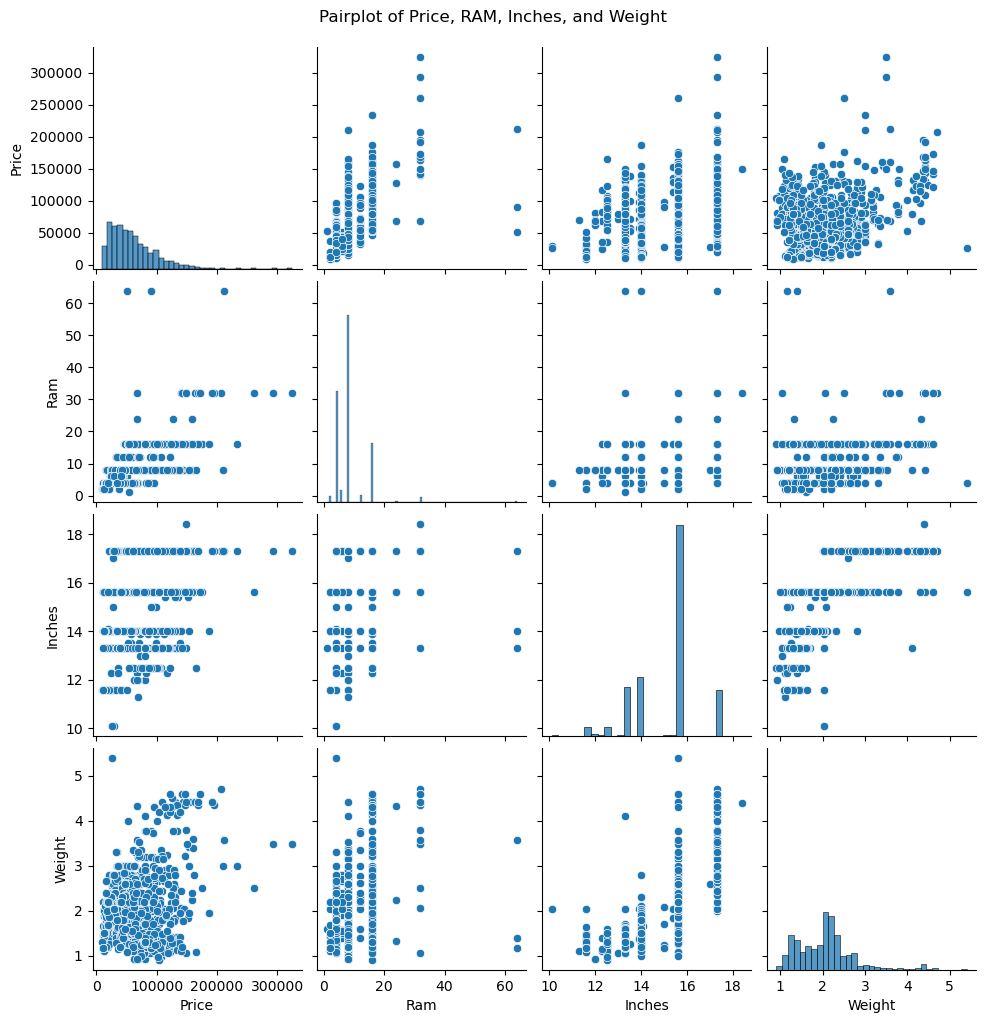

In [128]:
sns.pairplot(df[['Price', 'Ram', 'Inches', 'Weight']])
plt.suptitle('Pairplot of Price, RAM, Inches, and Weight', y=1.02)
plt.show()

## Average Price by Type and GPU Brand

In [129]:
df['GPU_Brand'] = df['Gpu'].str.split().str[0]

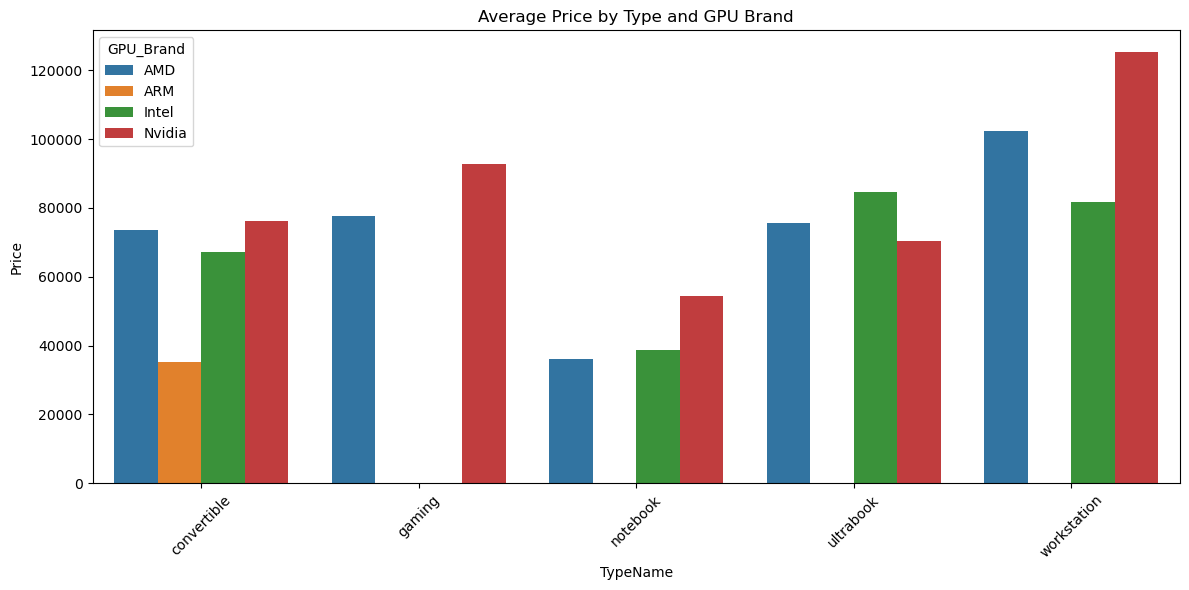

In [135]:
avg_price = df.groupby(['TypeName', 'GPU_Brand'])['Price'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='TypeName', y='Price', hue='GPU_Brand', data=avg_price)
plt.xticks(rotation=45)
plt.title('Average Price by Type and GPU Brand')
plt.tight_layout()
plt.show()


# Visualization

## Price Distribution

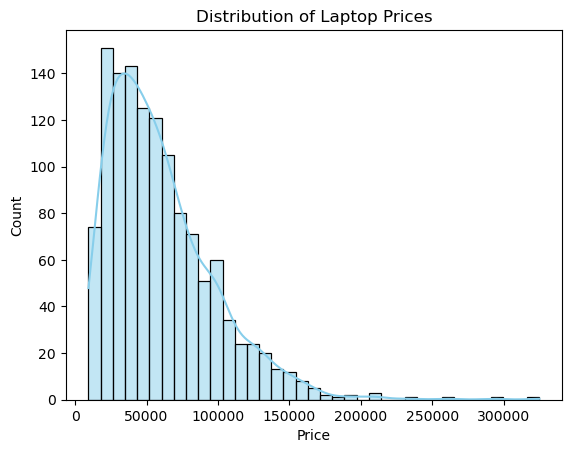

In [136]:
sns.histplot(df['Price'], kde=True, color='skyblue')
plt.title('Distribution of Laptop Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()


## Ram Distribution

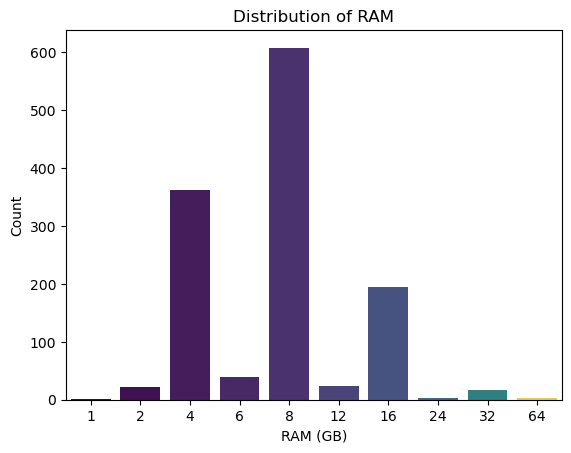

In [137]:
sns.countplot(x='Ram', hue='Ram', data=df, palette='viridis', legend=False)
plt.title('Distribution of RAM')
plt.xlabel('RAM (GB)')
plt.ylabel('Count')
plt.show()

##  Screen Size Distribution

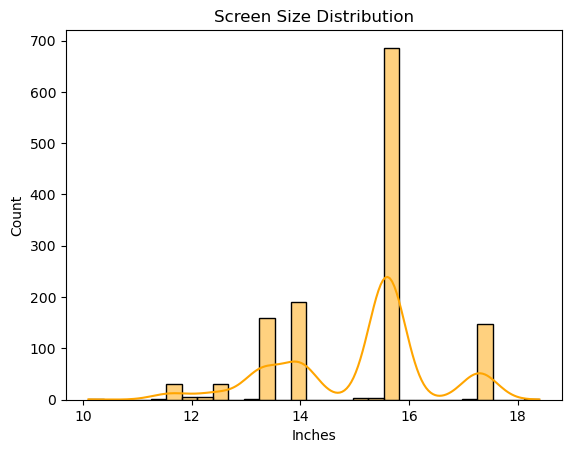

In [138]:
sns.histplot(df['Inches'], kde=True, color='orange')
plt.title('Screen Size Distribution')
plt.xlabel('Inches')
plt.ylabel('Count')
plt.show()


# Relationship Visuals

## Price vs. RAM

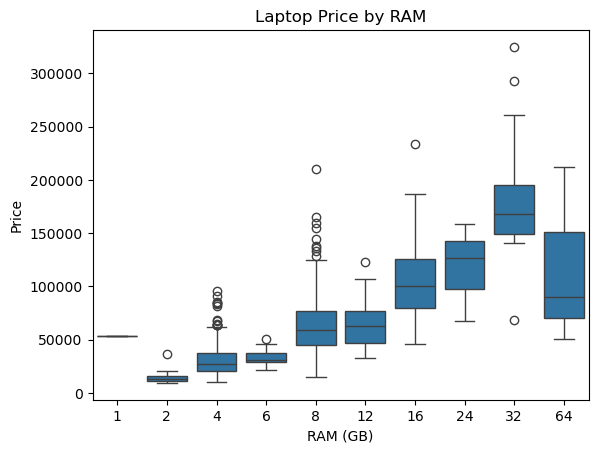

In [139]:
sns.boxplot(x='Ram', y='Price', data=df)
plt.title('Laptop Price by RAM')
plt.xlabel('RAM (GB)')
plt.ylabel('Price')
plt.show()


## Price vs. CPU Brand

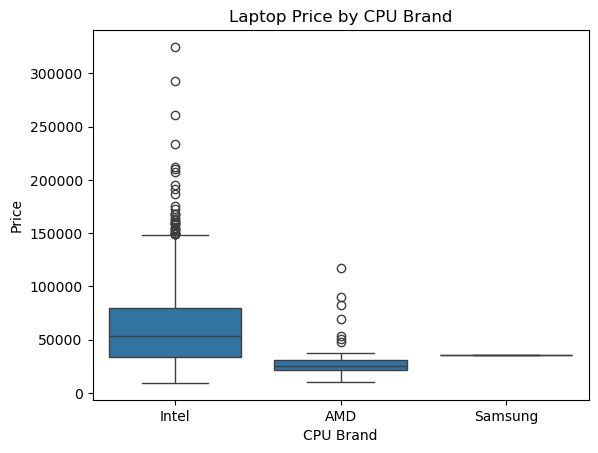

In [140]:
sns.boxplot(x='CPU_Brand', y='Price', data=df)
plt.title('Laptop Price by CPU Brand')
plt.xlabel('CPU Brand')
plt.ylabel('Price')
plt.show()

# Market Trends & Preferences

## Average Price by Laptop Type

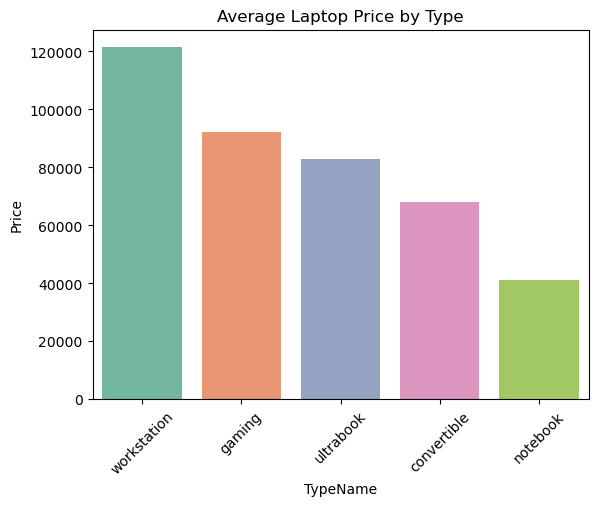

In [145]:
avg_price_type = df.groupby('TypeName')['Price'].mean().reset_index().sort_values(by='Price', ascending=False)

sns.barplot(x='TypeName', y='Price', hue='TypeName', data=avg_price_type, palette='Set2', legend=False)
plt.title('Average Laptop Price by Type')
plt.xticks(rotation=45)
plt.show()


## OS Preference

C:\Users\sanja\AppData\Local\Temp\ipykernel_14628\3485310779.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='OpSys', data=df, order=df['OpSys'].value_counts().index, palette='cool')


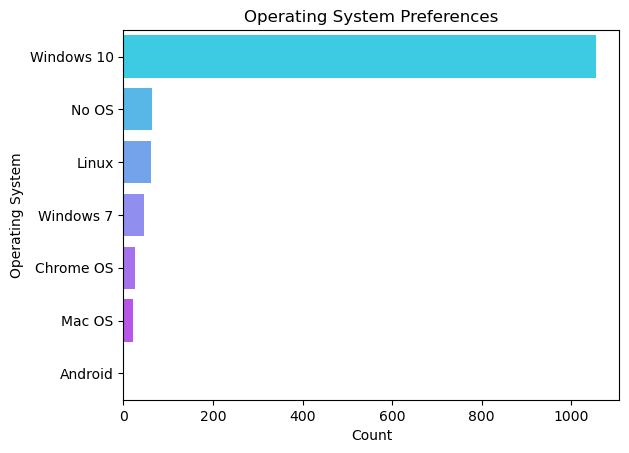

In [146]:
sns.countplot(y='OpSys', data=df, order=df['OpSys'].value_counts().index, palette='cool')
plt.title('Operating System Preferences')
plt.xlabel('Count')
plt.ylabel('Operating System')
plt.show()


# CPU Brand & Generation
- Extract CPU brand and generation to analyze performance tiers.

In [147]:
# CPU Brand
df['CPU_Brand'] = df['Cpu'].str.split().str[0]

# CPU Generation (e.g., 5th, 6th, 10th)
import re
def extract_gen(cpu):
    match = re.search(r'(\d{1,2})(?:th|-)?\s*Gen', cpu)
    if match:
        return int(match.group(1))
    digits = re.findall(r'i\d-(\d{3,4})', cpu)
    if digits:
        num = int(digits[0])
        return int(str(num)[0]) if len(str(num)) == 4 else None
    return None

df['CPU_Gen'] = df['Cpu'].apply(extract_gen)


##  GPU Brand

In [148]:
df['GPU_Brand'] = df['Gpu'].str.split().str[0]


## Storage Type (SSD vs HDD)

In [150]:
def storage_type(memory):
    memory = str(memory).upper()
    if 'SSD' in memory and 'HDD' in memory:
        return 'Hybrid'
    elif 'SSD' in memory:
        return 'SSD'
    elif 'HDD' in memory:
        return 'HDD'
    else:
        return 'Other'

df['Storage_Type'] = df['Memory'].apply(storage_type)


## Touchscreen (if applicable from ScreenResolution)

In [152]:
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)

## Brand Reputation (Optional Custom Mapping)
- Map top brands to "High", "Mid", "Low" reputation tiers (based on external logic or research)

In [153]:
def map_reputation(brand):
    if brand in ['Apple', 'Dell', 'HP', 'Lenovo']:
        return 'High'
    elif brand in ['Asus', 'Acer']:
        return 'Mid'
    else:
        return 'Low'

df['Brand_Reputation'] = df['Company'].apply(map_reputation)


## **1. Key Factors Influencing Laptop Pricing**

###  **RAM and CPU significantly affect price**

* Boxplots showed that laptops with higher RAM (≥8GB) and premium CPU brands (e.g., Intel i7/i9, AMD Ryzen) command **substantially higher prices**.
* **CPU Generation** also influences price — newer generations (10th, 11th Gen) generally cost more.

###  **GPU presence increases cost**

* Laptops with **NVIDIA or AMD dedicated GPUs** are **markedly more expensive**, often indicating gaming or workstation use.
* Integrated GPUs (e.g., Intel HD) are common in budget and ultrabook categories.

###  **Storage type matters**

* Laptops with **SSD or Hybrid (SSD + HDD)** storage are priced higher than HDD-only devices due to performance gains.

###  **Screen size and weight correlation**

* Larger screens (>15") tend to correlate with higher weight. Lighter, thinner models often fall under premium Ultrabooks, which cost more.

---

##  **2. Consumer Preferences and Market Trends**

###  **Brand Reputation impacts pricing**

* Brands like **Apple, Dell, Lenovo, and HP** have consistently higher average prices, reflecting consumer trust and premium build.
* **Acer, Asus** offer more budget-friendly models, often with competitive specs.

###  **Touchscreen and 2-in-1 designs are gaining popularity**

* A subset of laptops in the dataset includes Touchscreen-enabled devices, commonly in the **Convertible / Ultrabook** category — showing market demand for flexible devices.

###  **Operating System preferences**

* **Windows** remains dominant, while **macOS** is limited to Apple.
* Some laptops still come with **Linux/No OS**, appealing to technical or price-sensitive users.

---

##  **3. Recommendations**

###  **Product Differentiation**

* Offer mid-range laptops with **8GB RAM + SSD + Ryzen 5/i5 CPU** targeting performance-conscious budget users.
* Introduce **touchscreen + convertible models** in mid-tier price ranges to attract professionals and students.

###  **Pricing Strategies**

* Consider **value bundling** (e.g., SSD + high-res screen) to justify price hikes.
* For lower-tier brands, emphasize **spec-to-price ratio** to stay competitive.

###  **Marketing Suggestions**

* Promote **lightweight laptops (Ultrabooks)** for students and travelers.
* Highlight **GPU and screen refresh rate** for gaming laptops.
* Emphasize **brand reliability and customer support** for high-end segments.

---

